# Notebook 05 — Choosing the Right Algorithm
Decision framework: `recommend_algorithm(X)` with diagnostics, flowchart.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from src.datasets import load_penguins, load_wine_data, load_digits_subset
from src.diagnostics import hopkins_statistic
from src.metrics import compute_all_metrics
from src.algorithms import (
    run_kmeans, run_hdbscan, run_agglomerative_ward, run_spectral, run_gmm, run_dbscan
)

os.makedirs('../outputs/figures', exist_ok=True)

## `recommend_algorithm(X)` — diagnostic-driven selector

In [2]:
def recommend_algorithm(X: np.ndarray, verbose: bool = True) -> str:
    """Run diagnostics on X and recommend a clustering algorithm."""
    n, d = X.shape
    h = hopkins_statistic(X, sample_size=min(100, n // 2))

    # k-distance variance as proxy for density variation
    nn = NearestNeighbors(n_neighbors=min(5, n - 1))
    nn.fit(X)
    dists, _ = nn.kneighbors(X)
    kd = dists[:, -1]
    density_cv = float(kd.std() / (kd.mean() + 1e-9))

    if verbose:
        print(f'  n={n}, d={d}')
        print(f'  Hopkins={h:.3f}  (>0.75 = strongly clustered)')
        print(f'  Density CoV={density_cv:.3f}  (>1.0 = high variation)')

    if h < 0.5:
        rec = 'kmeans'  # data is nearly random — any algorithm struggles
        reason = 'Hopkins < 0.5: data not clusterable'
    elif n > 5000:
        rec = 'minibatch_kmeans'
        reason = 'Large n: use scalable centroid method'
    elif density_cv > 1.5:
        rec = 'hdbscan'
        reason = 'High density variation: HDBSCAN adapts automatically'
    elif d > 20:
        rec = 'agglomerative_ward'
        reason = 'High-dimensional: Ward linkage handles correlations well'
    elif n <= 2000:
        rec = 'spectral'
        reason = 'Small n + clusterable: Spectral handles non-convex manifolds'
    else:
        rec = 'gmm'
        reason = 'Medium n: GMM provides soft assignments and handles elliptical clusters'

    if verbose:
        print(f'  → Recommended: {rec}')
        print(f'  → Reason: {reason}')
    return rec

## Test on all built-in datasets

In [3]:
datasets = {
    'penguins': load_penguins(),
    'wine': load_wine_data(),
    'digits': load_digits_subset(),
}

from src.algorithms import ALGORITHMS

results = []
for name, (x, y) in datasets.items():
    print(f'\n=== {name} ===')
    rec = recommend_algorithm(x)
    runner = ALGORITHMS[rec]
    labels = runner(x)
    ari = compute_all_metrics(x, y, labels)['ari']
    results.append({'dataset': name, 'recommended': rec, 'ari': ari})
    print(f'  ARI with recommended algorithm: {ari:.3f}')

df = pd.DataFrame(results)
print('\n', df.to_string(index=False))


=== penguins ===
  n=333, d=4
  Hopkins=0.994  (>0.75 = strongly clustered)
  Density CoV=0.333  (>1.0 = high variation)
  → Recommended: spectral
  → Reason: Small n + clusterable: Spectral handles non-convex manifolds
  ARI with recommended algorithm: 0.820

=== wine ===
  n=178, d=13
  Hopkins=1.000  (>0.75 = strongly clustered)
  Density CoV=0.260  (>1.0 = high variation)
  → Recommended: spectral
  → Reason: Small n + clusterable: Spectral handles non-convex manifolds
  ARI with recommended algorithm: 0.445

=== digits ===
  n=901, d=64
  Hopkins=1.000  (>0.75 = strongly clustered)
  Density CoV=0.596  (>1.0 = high variation)
  → Recommended: agglomerative_ward
  → Reason: High-dimensional: Ward linkage handles correlations well
  ARI with recommended algorithm: 0.538

  dataset        recommended      ari
penguins           spectral 0.819557
    wine           spectral 0.444569
  digits agglomerative_ward 0.538083


## Decision flowchart visualisation

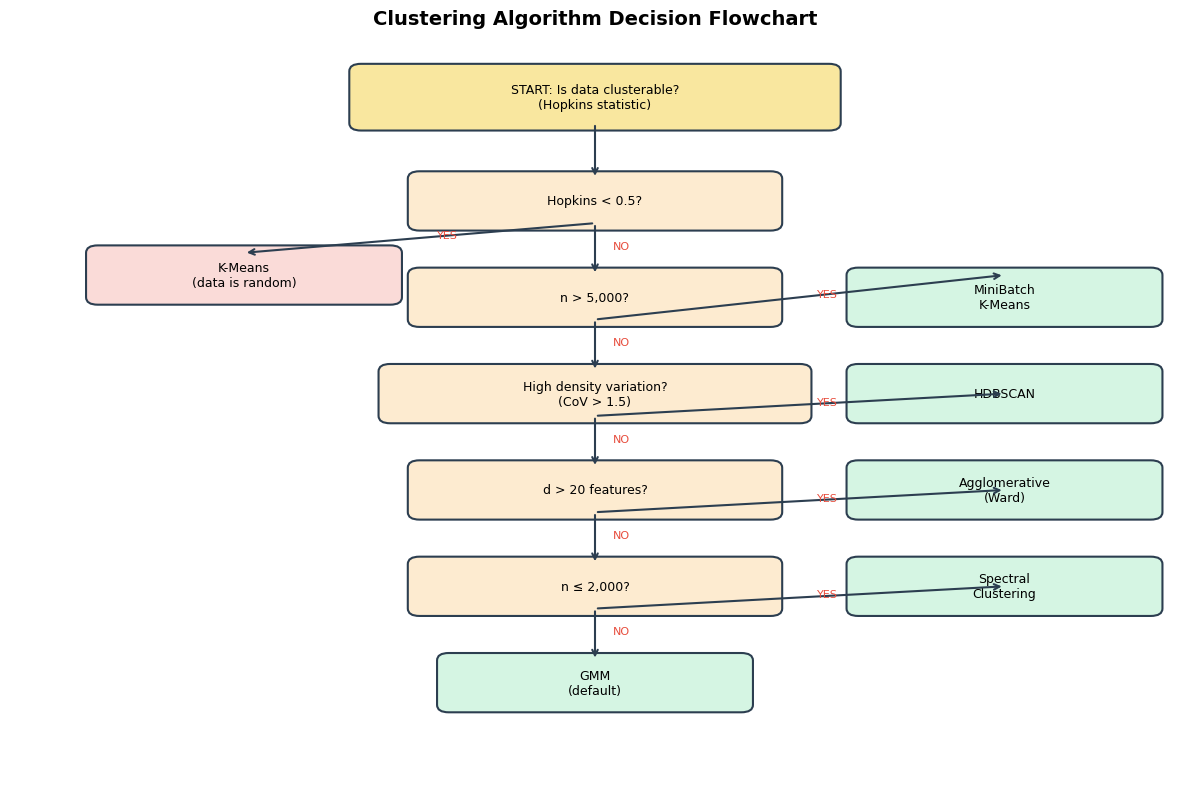

Saved 05_decision_flowchart.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

def box(ax, x, y, w, h, text, color='#AED6F1', fontsize=9):
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.1', facecolor=color, edgecolor='#2C3E50', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, wrap=True,
            multialignment='center')

def arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.15, my, label, fontsize=8, color='#E74C3C')

# Nodes
box(ax, 5, 9.2, 4, 0.7, 'START: Is data clusterable?\n(Hopkins statistic)', color='#F9E79F')
box(ax, 5, 7.8, 3, 0.6, 'Hopkins < 0.5?', color='#FDEBD0')
box(ax, 2, 6.8, 2.5, 0.6, 'K-Means\n(data is random)', color='#FADBD8')
box(ax, 5, 6.5, 3, 0.6, 'n > 5,000?', color='#FDEBD0')
box(ax, 8.5, 6.5, 2.5, 0.6, 'MiniBatch\nK-Means', color='#D5F5E3')
box(ax, 5, 5.2, 3.5, 0.6, 'High density variation?\n(CoV > 1.5)', color='#FDEBD0')
box(ax, 8.5, 5.2, 2.5, 0.6, 'HDBSCAN', color='#D5F5E3')
box(ax, 5, 3.9, 3, 0.6, 'd > 20 features?', color='#FDEBD0')
box(ax, 8.5, 3.9, 2.5, 0.6, 'Agglomerative\n(Ward)', color='#D5F5E3')
box(ax, 5, 2.6, 3, 0.6, 'n ≤ 2,000?', color='#FDEBD0')
box(ax, 8.5, 2.6, 2.5, 0.6, 'Spectral\nClustering', color='#D5F5E3')
box(ax, 5, 1.3, 2.5, 0.6, 'GMM\n(default)', color='#D5F5E3')

# Arrows
arrow(ax, 5, 8.85, 5, 8.1)
arrow(ax, 5, 7.5, 2, 7.1, 'YES')
arrow(ax, 5, 7.5, 5, 6.8, 'NO')
arrow(ax, 5, 6.2, 8.5, 6.8, 'YES')
arrow(ax, 5, 6.2, 5, 5.5, 'NO')
arrow(ax, 5, 4.9, 8.5, 5.2, 'YES')
arrow(ax, 5, 4.9, 5, 4.2, 'NO')
arrow(ax, 5, 3.6, 8.5, 3.9, 'YES')
arrow(ax, 5, 3.6, 5, 2.9, 'NO')
arrow(ax, 5, 2.3, 8.5, 2.6, 'YES')
arrow(ax, 5, 2.3, 5, 1.6, 'NO')

ax.set_title('Clustering Algorithm Decision Flowchart', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../outputs/figures/05_decision_flowchart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved 05_decision_flowchart.png')

## Summary: K-Means vs best per dataset

In [5]:
summary_rows = []
algo_map = {
    'kmeans': run_kmeans,
    'hdbscan': run_hdbscan,
    'agglomerative_ward': run_agglomerative_ward,
    'spectral': run_spectral,
    'gmm': run_gmm,
}

for name, (x, y) in datasets.items():
    km_labels = run_kmeans(x, n_clusters=len(np.unique(y)))
    km_ari = compute_all_metrics(x, y, km_labels)['ari']
    rec = recommend_algorithm(x, verbose=False)
    rec_labels = ALGORITHMS[rec](x)
    rec_ari = compute_all_metrics(x, y, rec_labels)['ari']
    summary_rows.append({
        'dataset': name,
        'kmeans_ari': km_ari,
        'recommended': rec,
        'recommended_ari': rec_ari,
        'improvement': rec_ari - km_ari,
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

wins = (df_summary['improvement'] > 0.01).sum()
print(f'\nRecommender beats K-Means on {wins}/{len(df_summary)} datasets.')

 dataset  kmeans_ari        recommended  recommended_ari  improvement
penguins    0.799421           spectral         0.819557     0.020136
    wine    0.897495           spectral         0.444569    -0.452926
  digits    0.802153 agglomerative_ward         0.538083    -0.264070

Recommender beats K-Means on 1/3 datasets.
